In [1]:
#Probabillity of success
#p(success) = p
#p(unsuccess) = 1-p


In [2]:
#P^k * (1-p)^k - p = this is called bernoulli dictribution

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#observed data
n = 20
k = 15

In [5]:
#analytical MLE
p_hat = k/n
print(f"Analytical MLE = {p_hat:.3f}" )

Analytical MLE = 0.750


In [6]:
p = np.linspace(0.001, 0.999, 500)

In [7]:
p

array([0.001, 0.003, 0.005, 0.007, 0.009, 0.011, 0.013, 0.015, 0.017,
       0.019, 0.021, 0.023, 0.025, 0.027, 0.029, 0.031, 0.033, 0.035,
       0.037, 0.039, 0.041, 0.043, 0.045, 0.047, 0.049, 0.051, 0.053,
       0.055, 0.057, 0.059, 0.061, 0.063, 0.065, 0.067, 0.069, 0.071,
       0.073, 0.075, 0.077, 0.079, 0.081, 0.083, 0.085, 0.087, 0.089,
       0.091, 0.093, 0.095, 0.097, 0.099, 0.101, 0.103, 0.105, 0.107,
       0.109, 0.111, 0.113, 0.115, 0.117, 0.119, 0.121, 0.123, 0.125,
       0.127, 0.129, 0.131, 0.133, 0.135, 0.137, 0.139, 0.141, 0.143,
       0.145, 0.147, 0.149, 0.151, 0.153, 0.155, 0.157, 0.159, 0.161,
       0.163, 0.165, 0.167, 0.169, 0.171, 0.173, 0.175, 0.177, 0.179,
       0.181, 0.183, 0.185, 0.187, 0.189, 0.191, 0.193, 0.195, 0.197,
       0.199, 0.201, 0.203, 0.205, 0.207, 0.209, 0.211, 0.213, 0.215,
       0.217, 0.219, 0.221, 0.223, 0.225, 0.227, 0.229, 0.231, 0.233,
       0.235, 0.237, 0.239, 0.241, 0.243, 0.245, 0.247, 0.249, 0.251,
       0.253, 0.255,

In [8]:
likelihood = p**k * (1-p)** (n-k)
log_likelihood = k*np.log(p) + (n-k)*np.log(1-p)

In [9]:
best_p = p[np.argmax(log_likelihood)]
print(f"Numerical MLE = {best_p:.3f}")

Numerical MLE = 0.749


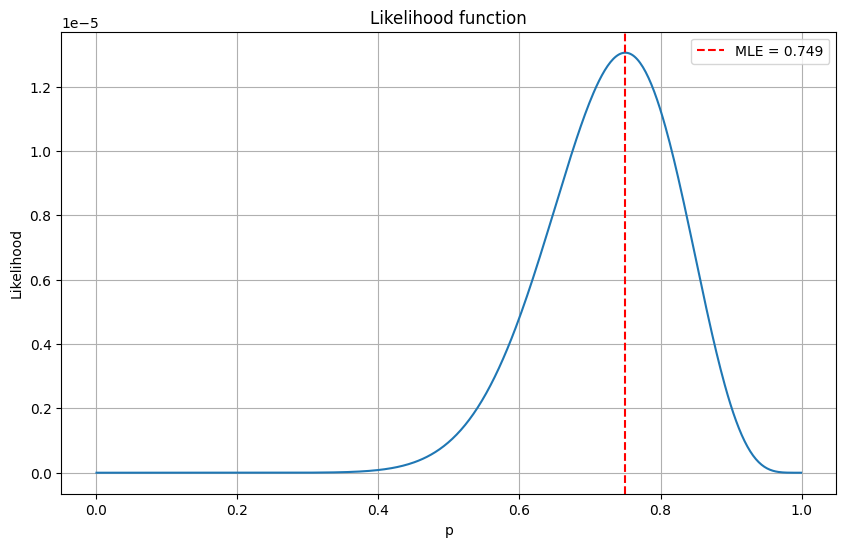

In [10]:
plt.figure(figsize=(10,6))
plt.plot(p, likelihood)
plt.axvline(best_p, color = "red", linestyle ="--", label =f"MLE = {best_p:.3f}")
plt.xlabel("p")
plt.ylabel("Likelihood")
plt.title("Likelihood function")
plt.grid(True)
plt.legend()
plt.show()


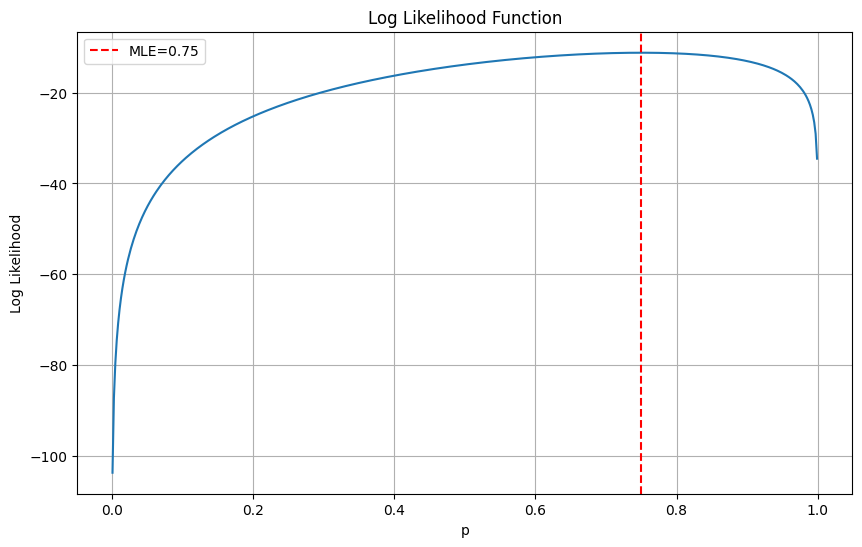

In [11]:

from matplotlib.lines import lineStyles
plt.figure(figsize=(10,6))
plt.plot(p, log_likelihood)
plt.axvline(best_p, color="red", linestyle="--", label=f"MLE={best_p:.2f}")
plt.title("Log Likelihood Function")
plt.xlabel("p")
plt.ylabel("Log Likelihood")
plt.grid(True)
plt.legend()


Classification predicts a discrete category or label, while regression predicts a continuous numerical value

In [12]:
import numpy as np
def sigmoid(x):
  return 1/(1+np.exp(-x))


In [13]:
sigmoid(10)

np.float64(0.9999546021312976)

In [14]:
#output in range(0-1)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [16]:
def generate_dataset():
  dataset = make_classification(n_samples = 30, n_features = 1, n_repeated = 0, n_redundant = 0, shift = 30, scale = 10, n_classes = 2 , n_clusters_per_class = 1, n_informative = 1, class_sep = 1, random_state = 1)
  df = pd.DataFrame(dataset[0])
  df = pd.concat([(np.ceil(df)).astype(int), pd.DataFrame(dataset[1])], axis = 1)
  df.columns = ["GRE_Score", "Admission"]
  return df

In [17]:
data = generate_dataset()
data.head()

,GRE_Score,Admission
0,287,0
1,295,0
2,317,1
3,300,0
4,310,1


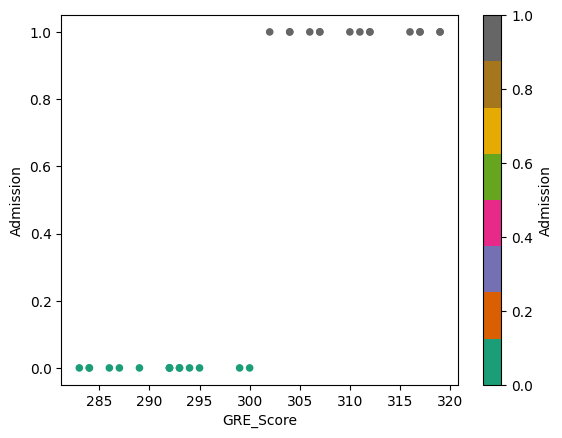

In [18]:
data.plot.scatter(x = "GRE_Score", y = "Admission", c = "Admission", cmap= "Dark2")
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression
map_color = np.array(['r', 'b'])
x = data[["GRE_Score"]].to_numpy()
y = data[["Admission"]].to_numpy()

In [20]:
x

array([[287],
       [295],
       [317],
       [300],
       [310],
       [289],
       [292],
       [299],
       [286],
       [302],
       [283],
       [307],
       [312],
       [311],
       [319],
       [304],
       [293],
       [306],
       [292],
       [293],
       [292],
       [284],
       [319],
       [284],
       [304],
       [316],
       [294],
       [317],
       [312],
       [307]])

In [21]:
y

array([[0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1]])

In [22]:
linearRegression = LinearRegression()
linearRegression.fit(x,y)

LinearRegression()

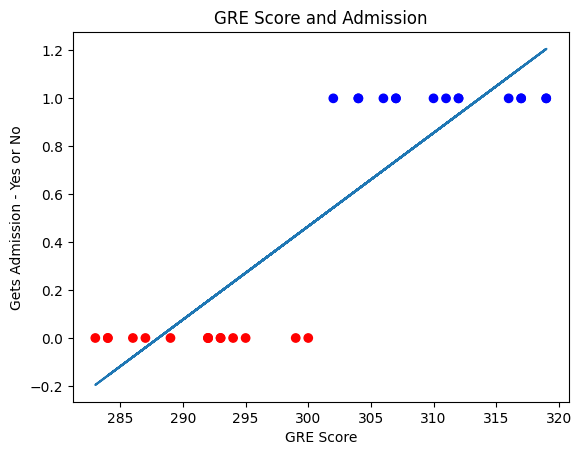

In [27]:
plt.scatter(x,y, c=map_color[y.ravel()])
plt.plot(x,linearRegression.predict(x))
plt.title("GRE Score and Admission")
plt.xlabel('GRE Score')
plt.ylabel('Gets Admission - Yes or No')
plt.show()

In [23]:
y_hat = linearRegression.predict(x)

In [24]:
prob_y = sigmoid(y_hat)

In [25]:
prob_y

array([[0.48998784],
       [0.56746495],
       [0.75553096],
       [0.614495  ],
       [0.70176329],
       [0.50945847],
       [0.53859234],
       [0.60522885],
       [0.48026021],
       [0.63277474],
       [0.45119618],
       [0.67674872],
       [0.71780529],
       [0.70984984],
       [0.76963023],
       [0.65068043],
       [0.54825514],
       [0.66817089],
       [0.53859234],
       [0.54825514],
       [0.53859234],
       [0.46085711],
       [0.76963023],
       [0.46085711],
       [0.65068043],
       [0.74826606],
       [0.55788169],
       [0.75553096],
       [0.71780529],
       [0.67674872]])

In [26]:
threshold = 0.5
result = prob_y > threshold
result.astype(int).flatten()

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1])